# Validation Sequence

## August 2026 Forecast

## Emily Zuetell

# Initialization

In [2]:
import os
from pathlib import Path
from dotenv import load_dotenv, find_dotenv
import xarray as xr

import geopandas as gpd
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt

import analysis_utils
import isku_utils

import importlib
importlib.reload(analysis_utils)
importlib.reload(isku_utils)

<module 'isku_utils' from '/home/emily_zuetell/projects/poreallas/analysis/isku_utils.py'>

In [1]:
load_dotenv()
DATA_DIR = os.environ["DATA_DIR"]
#EFFECTS_URI = os.environ["POREALLAS_EFFECTS_URI"]
EFFECTS_URI = "/home/emily_zuetell/projects/poreallas/data/2608_effect_gamma_sampled.zarr"
IMPACT_REGION_POLYGONS = os.environ["POREALLAS_REGIONS_POLYGONS_URI"]
SOCIOECONOMICS_URI = os.environ["POREALLAS_SOCIOECONOMICS_URI"]

#Climate Data
TAS_FORECAST_URI = os.environ["POREALLAS_TAS_FORECAST_URI"]
ERA5_URI = os.environ["POREALLAS_ERA5_URI"]

TAS_FORECAST_RAW = os.environ[POREALLAS_TAS_FORECAST_RAW_URI]

NameError: name 'load_dotenv' is not defined

In [3]:
#Projection Effects
effect = xr.open_datatree(os.path.join(DATA_DIR, EFFECTS_URI), consolidated = False)
baseline_period = analysis_utils.get_baseline_period(effect, years = 30)
#Impact Regions
_polygons = (
    gpd.read_parquet(IMPACT_REGION_POLYGONS)
    .rename(columns={"hierid": "region"})
    .set_index("region")
    .set_crs(epsg=4326)  # Assuming the data is WGS-82.
)

#Socioeconomics
socioeconomics =  xr.open_zarr(SOCIOECONOMICS_URI)
socioeconomics = socioeconomics.sel(year = 2026)[['pop0to4', 'pop5to64', 'pop65plus', 'pop', 'gdppc', 'iso3']]

# Raw Climate Anomaly

Computed from the raw forecast (Aug 2026-Jan 2027) compared to the hindcast over the full available period (1981-2025)*

In [4]:
#Raw Forecast/Hindcast
s51 = xr.open_zarr("/home/emily_zuetell/projects/poreallas/data/parsed/08_ecmwf_parsed.zarr")
forecast_raw = s51.sel(time=slice('2026-08-01', '2027-01-31')).groupby("time.month").mean()
hindcast_raw = s51.sel(time=slice('1993-08-01', '2016-01-31')).groupby("time.month").mean().sel(month = [1, 8, 9, 10, 11, 12])

In [5]:
#Compute monthly average anomaly
anomaly = forecast_raw['tas']-hindcast_raw['tas']
anomaly.name = "forecast_anomaly"

In [6]:
anomaly_grid_land = analysis_utils.land_only(anomaly.sel(month = 8).mean(dim = 'number'))

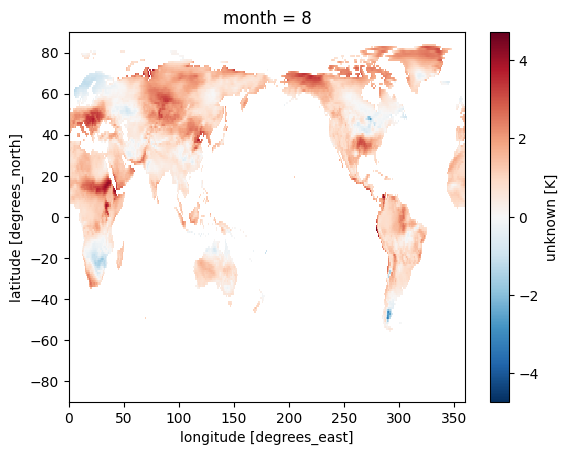

In [7]:
anomaly_grid_land.plot()
plt.show()

In [17]:
## Gridded to Impact Region
anomaly_ir = isku_utils.grid_to_ir(anomaly.compute(), savefile = None)
_polygons_anomaly = analysis_utils.xarray_to_gpd(anomaly_ir.mean(dim = 'number'), _polygons)
_polygons_anomaly_std = analysis_utils.xarray_to_gpd(anomaly_ir.std(dim = 'number'), _polygons)



/home/emily_zuetell/projects/poreallas/analysis/isku_utils.py:31: RuntimeWarning: Failed to open Zarr store with consolidated metadata, but successfully read with non-consolidated metadata. This is typically much slower for opening a dataset. To silence this warning, consider:
1. Consolidating metadata in this existing store with zarr.consolidate_metadata().
2. Explicitly setting consolidated=False, to avoid trying to read consolidate metadata, or
3. Explicitly setting consolidated=True, to raise an error in this case instead of falling back to try reading non-consolidated metadata.
  _region_weights = xr.load_dataset(uri)[
/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/zarr/core/group.py:3289: ZarrUserWarning: Object at zarr.json:Zone.Identifier is not recognized as a component of a Zarr hierarchy.
  warnings.warn(


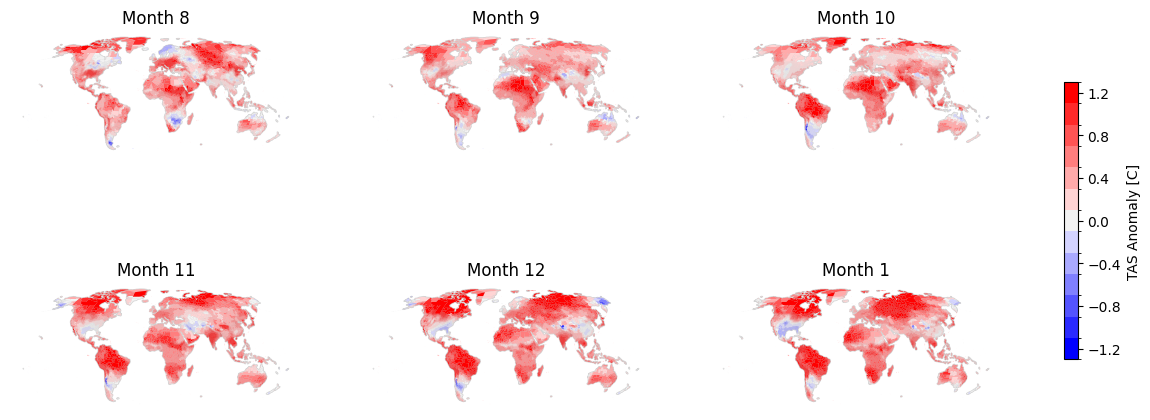

In [52]:
fig = analysis_utils.plot_monthly(
    _polygons_anomaly,
    col='value',
    cm = 'bwr',
    n_colors = 9,
    sup_title=f"",
    cbar_label= 'TAS Anomaly [C]',
    month_order= [8, 9, 10, 11, 12, 1]
)

fig.savefig("2608_monthly_anomaly.png", dpi = 600, bbox_inches="tight")

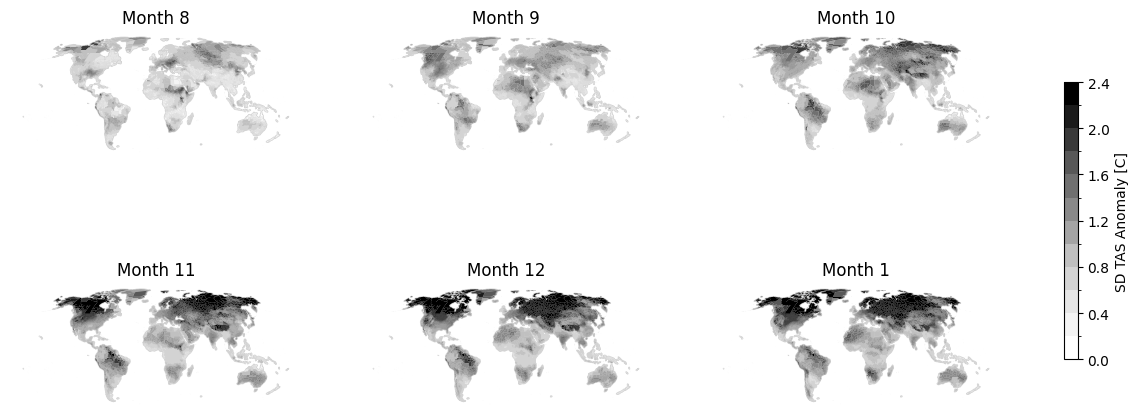

In [53]:
fig = analysis_utils.plot_monthly(
    _polygons_anomaly_std,
    col='value',
    cm = 'Grays',
    n_colors = 9,
    vmin = 0,
    sup_title=f"",
    cbar_label= 'SD TAS Anomaly [C]',
    month_order= [8, 9, 10, 11, 12, 1]
)

fig.savefig("2608_monthly_anomaly_std.png", dpi = 600, bbox_inches="tight")

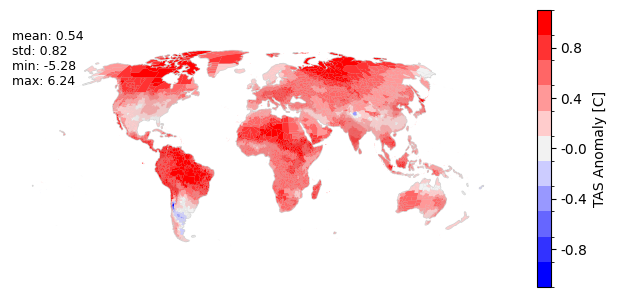

In [18]:
#Validation Annotation
annotation = analysis_utils.build_stats_text(anomaly_ir.mean(dim = 'month'))
#6 month average anomaly
fig = analysis_utils.plot_aggregate(
    _polygons_anomaly,
    col='value',
    agg = 'mean',
    cm = 'bwr',
    n_colors = 7,
    annotation=annotation,
    sup_title=f"",
    cbar_label= 'TAS Anomaly [C]',
)

fig.savefig("2608_cum_anomaly_CDS_baseline.png", dpi = 600, bbox_inches="tight")

## Forecast Quantile Map

In [4]:
forecast = s51.sel(time=slice('2026-08-01', '2026-08-31'))
hindcast = s51.sel(time=s51.time.dt.month == 8)

In [127]:
hindcast

<xarray.Dataset> Size: 18GB
Dimensions:                  (number: 51, latitude: 180, longitude: 360,
                              time: 1380)
Coordinates:
  * number                   (number) int64 408B 0 1 2 3 4 5 ... 46 47 48 49 50
  * latitude                 (latitude) float64 1kB 89.5 88.5 ... -88.5 -89.5
  * longitude                (longitude) float64 3kB 0.5 1.5 2.5 ... 358.5 359.5
  * time                     (time) object 11kB 1981-08-02 00:00:00 ... 2026-...
    forecast_period          (time) timedelta64[ns] 11kB dask.array<chunksize=(1380,), meta=np.ndarray>
    forecast_reference_time  (time) datetime64[ns] 11kB dask.array<chunksize=(1380,), meta=np.ndarray>
Data variables:
    tas                      (number, latitude, longitude, time) float32 18GB dask.array<chunksize=(51, 30, 2, 1380), meta=np.ndarray>
Attributes:
    poreallas_created_at:   2026-08-06T16:07:16.417760+00:00
    poreallas_uid:          5fa02d07-3f21-4c51-81e1-eef50b730e39
    poreallas_description:  Parsed ECMWF S51 ensemble fields

In [5]:
import xsdba

In [6]:
ptile = xsdba.utils.rank(hindcast, "time", pct=True)
ptile_land = analysis_utils.land_only(ptile)

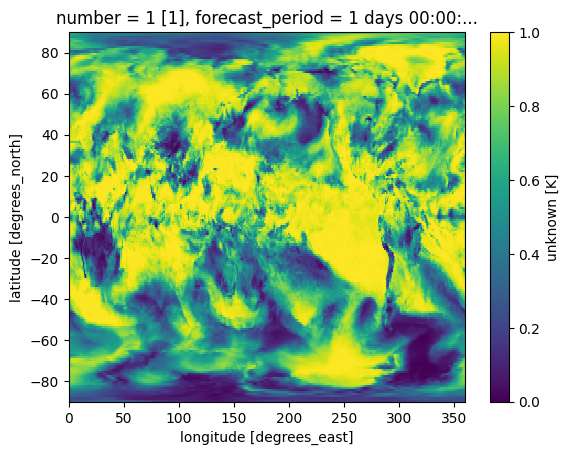

In [ ]:
da = ptile['tas'].sel(number = 1, time = "2026-08-02")
da_land = analysis_utils.land_only(da)
da_land.plot()

In [12]:
ptile_land['tas'].sel(time = slice('2026-08-02', '2026-08-31'))

<xarray.DataArray 'tas' (number: 51, lat: 180, lon: 360, time: 30)> Size: 793MB
dask.array<getitem, shape=(51, 180, 360, 30), dtype=float64, chunksize=(51, 30, 2, 30), chunktype=numpy.ndarray>
Coordinates:
  * number                   (number) int64 408B 0 1 2 3 4 5 ... 46 47 48 49 50
  * lat                      (lat) float64 1kB 89.5 88.5 87.5 ... -88.5 -89.5
  * lon                      (lon) float64 3kB 0.5 1.5 2.5 ... 357.5 358.5 359.5
  * time                     (time) object 240B 2026-08-02 00:00:00 ... 2026-...
    forecast_period          (time) timedelta64[ns] 240B dask.array<chunksize=(30,), meta=np.ndarray>
    forecast_reference_time  (time) datetime64[ns] 240B dask.array<chunksize=(30,), meta=np.ndarray>
Attributes: (12/31)
    GRIB_dataType:                            fc
    GRIB_numberOfPoints:                      64800
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    GRIB_gridType:                            regular_ll
    ...                                       ...
    units:                                    K
    standard_name:                            unknown
    GRIB_surface:                             0.0
    poreallas_created_at:                     2026-08-06T16:07:16.417760+00:00
    poreallas_uid:                            5fa02d07-3f21-4c51-81e1-eef50b7...
    poreallas_description:                    Parsed ECMWF S51 ensemble tas f...

In [23]:
%matplotlib inline

/tmp/ipykernel_1078/4211278673.py:2: FutureWarning: In a future version of xarray to_datetimeindex will default to returning a 'us'-resolution DatetimeIndex instead of a 'ns'-resolution DatetimeIndex. This warning can be silenced by explicitly passing the `time_unit` keyword argument.
  da = da.assign_coords(time=da.indexes["time"].to_datetimeindex(unsafe=True))


<function matplotlib.pyplot.show(close=None, block=None)>

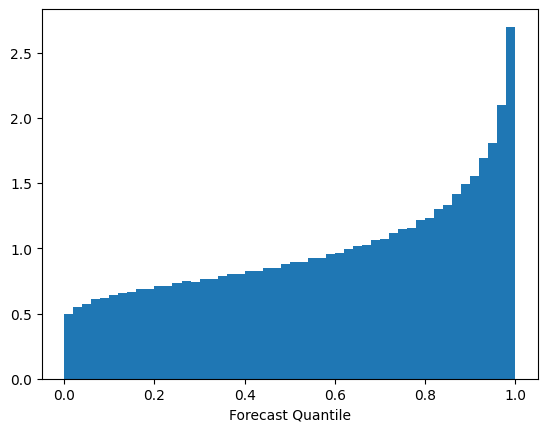

In [29]:
da = ptile_land['tas'].sel(time = slice('2026-08-02', '2026-08-31'))
da = da.assign_coords(time=da.indexes["time"].to_datetimeindex(unsafe=True))
da.plot.hist(bins = 50, density = True)
plt.xlabel("Forecast Quantile")
plt.show

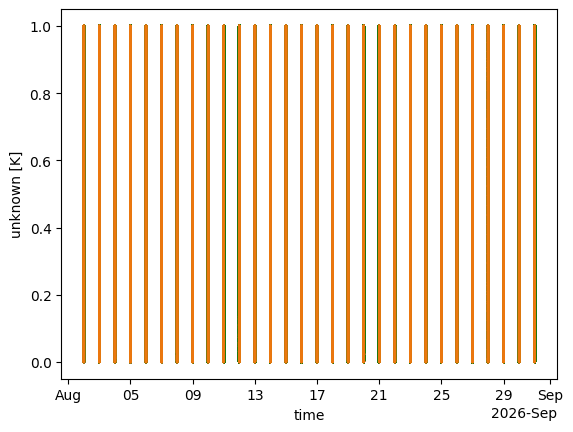

In [25]:
plt.show()

# QDM Bias Correction

In [76]:
qdm = xr.open_zarr("/home/emily_zuetell/projects/poreallas/data/08_qdm_gmfd.zarr")
qdm_land = analysis_utils.land_only(qdm)

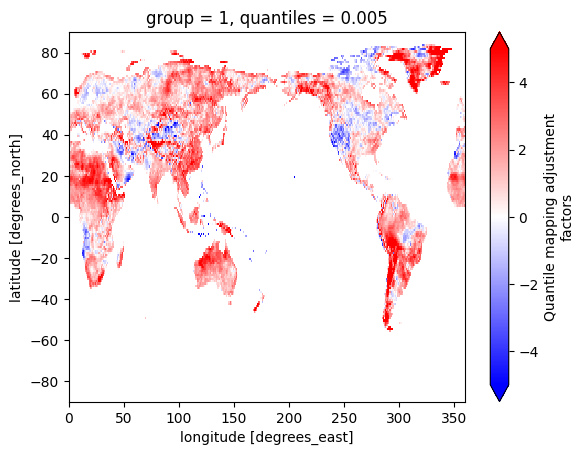

In [81]:
qdm_land.af.sel(quantiles = 0, method = 'nearest').plot(vmin = -5, vmax = 5, cmap = 'bwr')

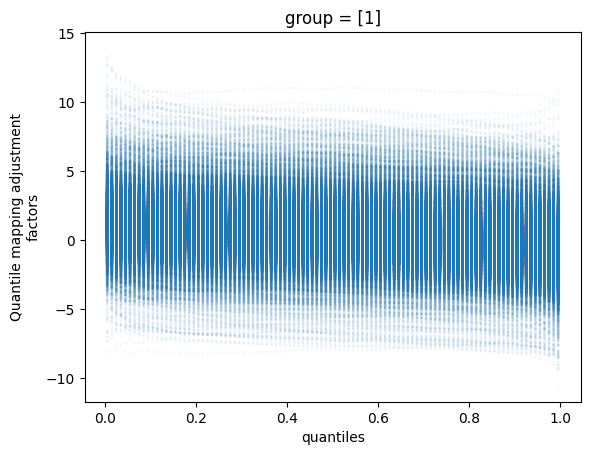

In [82]:
qdm_land.af.plot.scatter(x="quantiles", s=4, alpha=0.05, edgecolor="none")

In [109]:
fc_adj = xr.open_zarr("/home/emily_zuetell/projects/poreallas/data/2608_forecast_adj_corrected.zarr")
fc_adj = fc_adj.sortby("time")
era5_adj = xr.open_zarr("/home/emily_zuetell/projects/poreallas/data/era5_adj_corrected.zarr")

In [96]:
era5_raw = xr.open_zarr("/home/emily_zuetell/projects/poreallas/scripts/data/era5_daily_1993_2025")

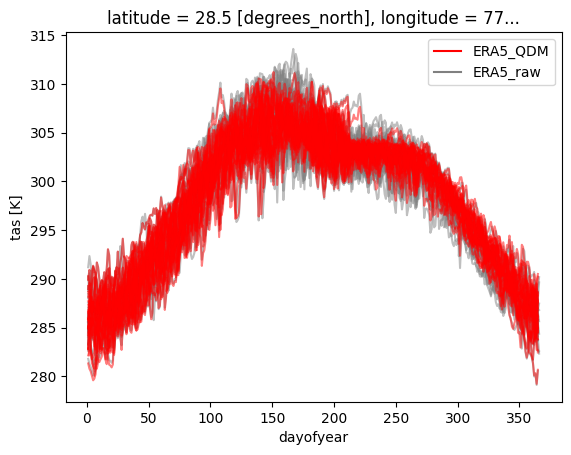

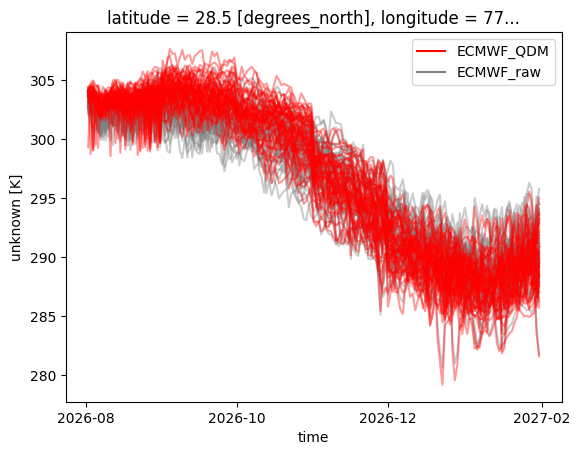

In [123]:
#lat, lon = 47.1625, 19.5033
lat, lon = 28.6139, 77.2090

fig, ax = plt.subplots()
da = era5_raw.sel(lat = lat, lon = lon, method = 'nearest')['tas']
da2 = da.assign_coords(year=da.time.dt.year, dayofyear=da.time.dt.dayofyear)
da2 = da2.set_index(time=["year", "dayofyear"]).unstack("time")
da2.plot.line(x="dayofyear", hue="year", color = 'gray', ax = ax, add_legend=False, alpha=0.5)

da = era5_adj.sel(latitude = lat, longitude = lon, method = 'nearest')['tas']
da2 = da.assign_coords(year=da.time.dt.year, dayofyear=da.time.dt.dayofyear)
da2 = da2.set_index(time=["year", "dayofyear"]).unstack("time")
da2.plot.line(x="dayofyear", hue="year", color = 'red',ax = ax, add_legend=False, alpha=0.5)

from matplotlib.lines import Line2D

handles = [
    Line2D([0], [0], color="red", label="ERA5_QDM"),
    Line2D([0], [0], color="gray", label="ERA5_raw"),
]
ax.legend(handles=handles)

fig, ax = plt.subplots()
s51.sel(time=slice('2026-08-01', '2027-01-31')).sel(latitude = lat, longitude = lon, method = 'nearest')['tas'].plot.line(x="time", hue="number", color = 'gray', alpha = 0.4, add_legend=False, ax=ax)
fc_adj.sel(latitude = lat, longitude = lon, method = 'nearest')['tas'].plot.line(x="time", hue="number", color = 'red', alpha = 0.4, add_legend=False, ax=ax)


handles = [
    Line2D([0], [0], color="red", label="ECMWF_QDM"),
    Line2D([0], [0], color="gray", label="ECMWF_raw"),
]
ax.legend(handles=handles)

In [92]:
forecast_raw

<xarray.Dataset> Size: 79MB
Dimensions:    (month: 6, number: 51, latitude: 180, longitude: 360)
Coordinates:
  * month      (month) int64 48B 1 8 9 10 11 12
  * number     (number) int64 408B 0 1 2 3 4 5 6 7 8 ... 43 44 45 46 47 48 49 50
  * latitude   (latitude) float64 1kB 89.5 88.5 87.5 86.5 ... -87.5 -88.5 -89.5
  * longitude  (longitude) float64 3kB 0.5 1.5 2.5 3.5 ... 357.5 358.5 359.5
Data variables:
    tas        (month, number, latitude, longitude) float32 79MB dask.array<chunksize=(6, 51, 30, 2), meta=np.ndarray>
Attributes:
    poreallas_created_at:   2026-08-06T16:07:16.417760+00:00
    poreallas_uid:          5fa02d07-3f21-4c51-81e1-eef50b730e39
    poreallas_description:  Parsed ECMWF S51 ensemble fields

# Climate Input Data (Bias-Corrected)

# Socioeconomic Input Data

# Projections

# Uncertainty